<a href="https://colab.research.google.com/github/ds-3289/Energy-Consumption-Predictor/blob/main/Energy_Consumption_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install missing libraries if required
!pip install seaborn matplotlib scikit-learn pandas
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Energy_Consumption.zip to Energy_Consumption.zip


In [ ]:
!unzip Energy_Consumption.zip

Archive:  Energy_Consumption.zip
  inflating: energy-consumption-2020-1.csv  


In [ ]:
# Load dataset
data = pd.read_csv('energy-consumption-2020-1.csv')
# Quick look
data.head()
# data.info()

,Site Name,Department,Year,Current Solar,Electric Utility,Electricity Usage,Peak Electric Demand,Building Type,Building Area,Natural Gas Usage,Energy Use Intensity,Address,Latitude,Longitude
0,PHX Building 139,Aviation,2020,0,APS,1,0,REPAIRSERVICES,3616,0,0.0,2745 E Air Ln,33.44299,-112.02176
1,Old Verde Park Cntr,Parks,2020,0,APS,12,0,UNKNOWN,0,0,NaN,916 E Van Buren St,33.45205,-112.06179
2,North Ranger Station - Old,Parks,2020,0,APS,77,0,OFFICE,0,0,NaN,11659 N 16th St,33.59485,-112.04768
3,Lookout Mountain Trailhead,Parks,2020,0,APS,242,0,OUTDOORREC,0,0,NaN,15415 N 16th St,33.62720,-112.04820
4,Laveen Basin,Parks,2020,0,SRP,317,0,PARK,0,0,NaN,6039 S 43rd Ave,33.39098,-112.14917


In [ ]:
data.describe()

,Year,Current Solar,Electricity Usage,Peak Electric Demand,Building Area,Natural Gas Usage,Energy Use Intensity,Latitude,Longitude
count,496.0,496.000000,4.960000e+02,496.000000,4.960000e+02,496.000000,280.000000,489.000000,489.000000
mean,2020.0,18.570565,5.360974e+05,194.112903,2.769305e+04,1785.520161,83.157536,33.505784,-112.071781
std,0.0,201.573224,3.454466e+06,1115.499161,1.374057e+05,15412.935269,197.958393,0.101549,0.061346
min,2020.0,0.000000,1.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,33.291660,-112.288850
25%,2020.0,0.000000,2.823350e+04,0.000000,0.000000e+00,0.000000,30.342500,33.438240,-112.107440
50%,2020.0,0.000000,8.811800e+04,38.000000,3.743500e+03,0.000000,46.000000,33.471410,-112.071870
75%,2020.0,0.000000,2.138845e+05,104.500000,1.357475e+04,113.250000,68.562500,33.582570,-112.029420
max,2020.0,4100.000000,6.952790e+07,22957.000000,1.918732e+06,297702.000000,2055.030000,33.806080,-111.746200


In [ ]:
# Safe handling of missing 'Datetime'
if 'Date' in data.columns and 'Time' in data.columns:
    data['Datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], errors='coerce')
    data.drop(['Date','Time'], axis=1, inplace=True)

# Fill missing numeric columns safely
for col in data.select_dtypes(include=np.number).columns:
    data[col] = data[col].fillna(data[col].median())

# If Datetime exists, drop missing rows
if 'Datetime' in data.columns:
    data.dropna(subset=['Datetime'], inplace=True)

# Remove duplicates and reset index
data.drop_duplicates(inplace=True)
data.reset_index(drop=True, inplace=True)

In [ ]:
print(data.columns.tolist())

['Site Name', 'Department', 'Year', 'Current Solar', 'Electric Utility', 'Electricity Usage', 'Peak Electric Demand', ' Building Type ', 'Building Area', 'Natural Gas Usage', 'Energy Use Intensity', 'Address', 'Latitude', 'Longitude']


In [ ]:
data.columns = data.columns.str.strip()
target = 'Electricity Usage'
features = ['Year', 'Current Solar', 'Peak Electric Demand', 'Building Area']  # numeric features only

X = data[features]
y = data[target]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Step 3 — Data Preprocessing
import pandas as pd
import numpy as np
# Clean column names
data.columns = data.columns.str.strip()
# Check for missing values
print("Missing values per column:\n", data.isnull().sum())
# Fill numeric columns with median
numeric_cols = ['Year', 'Current Solar', 'Peak Electric Demand', 'Building Area',
                'Electricity Usage', 'Natural Gas Usage', 'Energy Use Intensity']
for col in numeric_cols:
    if col in data.columns:
        data[col] = data[col].fillna(data[col].median())
# Remove duplicate rows
data.drop_duplicates(inplace=True)

# Optional: drop rows with missing critical info
data.dropna(subset=['Electricity Usage'], inplace=True)
print("\nData after preprocessing:")
print(data.info())

Missing values per column:
 Site Name               0
Department              0
Year                    0
Current Solar           0
Electric Utility        0
Electricity Usage       0
Peak Electric Demand    0
Building Type           0
Building Area           0
Natural Gas Usage       0
Energy Use Intensity    0
Address                 0
Latitude                0
Longitude               0
dtype: int64

Data after preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 493 entries, 0 to 492
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Site Name             493 non-null    object 
 1   Department            493 non-null    object 
 2   Year                  493 non-null    int64  
 3   Current Solar         493 non-null    int64  
 4   Electric Utility      493 non-null    object 
 5   Electricity Usage     493 non-null    int64  
 6   Peak Electric Demand  493 non-null    int64  
 7  

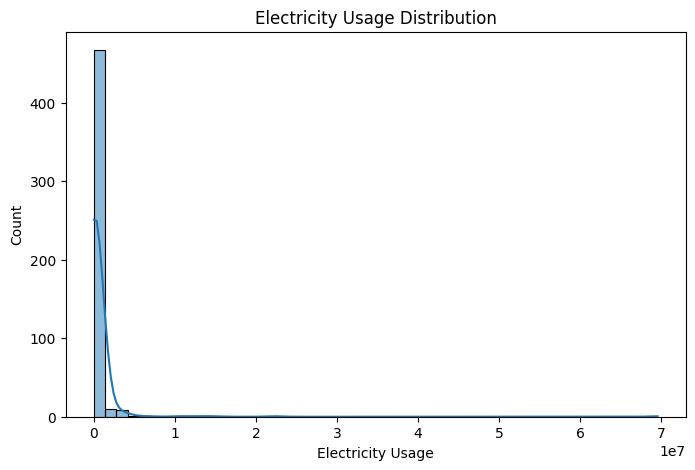

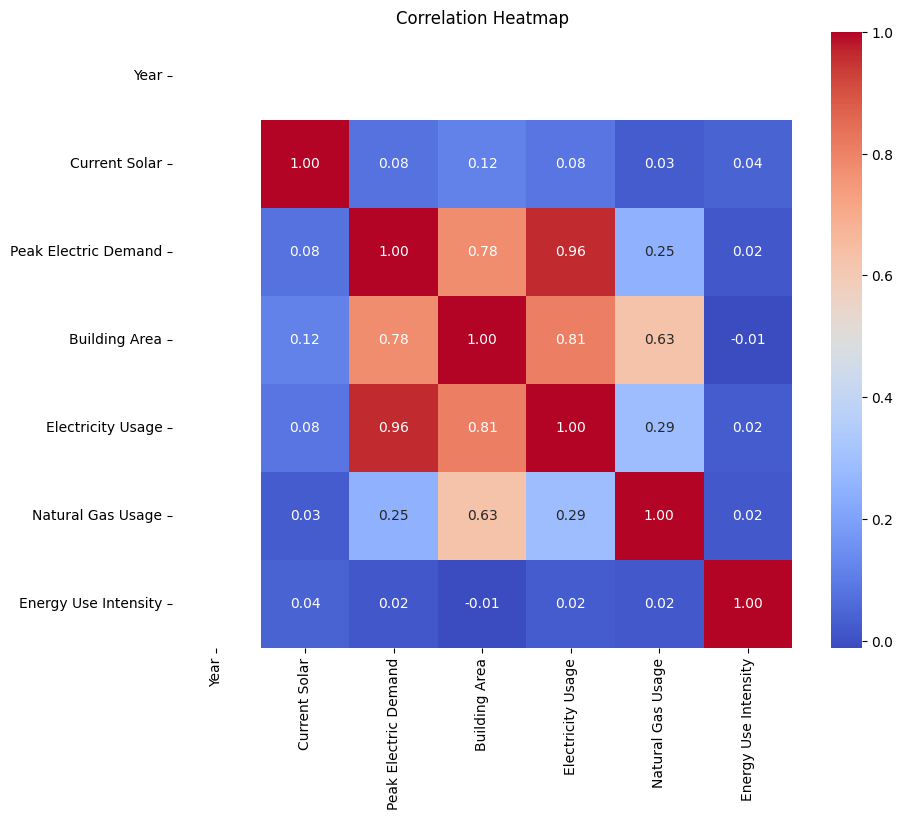

In [ ]:
# Step 4 — Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
# Histogram of Electricity Usage
plt.figure(figsize=(8,5))
sns.histplot(data['Electricity Usage'], bins=50, kde=True)
plt.title('Electricity Usage Distribution')
plt.xlabel('Electricity Usage')
plt.show()
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Step 5 — Feature Engineering / Selection
# Choose features and target
features = ['Year', 'Current Solar', 'Peak Electric Demand', 'Building Area']
target = 'Electricity Usage'
X = data[features]
y = data[target]
# Normalize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Feature matrix shape:", X_scaled.shape)
print("Target shape:", y.shape)

Feature matrix shape: (493, 4)
Target shape: (493,)


In [ ]:
# Step 6 — Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (394, 4)
Test set: (99, 4)


In [ ]:
# Step 7 — Apply Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree R2:", r2_score(y_test, y_pred_dt))
# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Linear Regression R2: 0.8196151511367914
Decision Tree R2: 0.5190226499804385
Random Forest R2: 0.6450688688816034


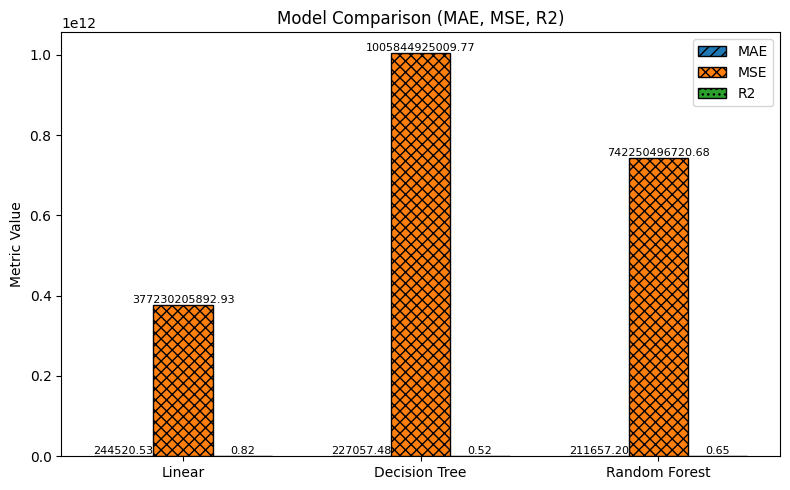

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model names
models = ["Linear", "Decision Tree", "Random Forest"]

# Metrics
mae = [
    mean_absolute_error(y_test, y_pred_lr),
    mean_absolute_error(y_test, y_pred_dt),
    mean_absolute_error(y_test, y_pred_rf)
]

mse = [
    mean_squared_error(y_test, y_pred_lr),
    mean_squared_error(y_test, y_pred_dt),
    mean_squared_error(y_test, y_pred_rf)
]

r2 = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf)
]

# X positions
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))

# Black & White bars using hatches
bars1 = plt.bar(x - width, mae, width, label="MAE", hatch='///', edgecolor='black')
bars2 = plt.bar(x, mse, width, label="MSE", hatch='xxx', edgecolor='black')
bars3 = plt.bar(x + width, r2, width, label="R2", hatch='...', edgecolor='black')

# Labels & title
plt.xticks(x, models)
plt.ylabel("Metric Value")
plt.title("Model Comparison (MAE, MSE, R2)")
plt.legend()

# Add value labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=8)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.tight_layout()

# Save high-quality image for print
plt.savefig("model_comparison_mse_final.png", dpi=300)

plt.show()

In [ ]:
# Step 8 — Model Evaluation
def evaluate_model(y_true, y_pred, name):
    print(f"\n{name} Evaluation:")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("R2 Score:", r2_score(y_true, y_pred))
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, "Random Forest")


Linear Regression Evaluation:
MAE: 244520.53495296062
MSE: 377230205892.9272
R2 Score: 0.8196151511367914

Decision Tree Evaluation:
MAE: 227057.48407407405
MSE: 1005844925009.7749
R2 Score: 0.5190226499804385

Random Forest Evaluation:
MAE: 211657.20106465463
MSE: 742250496720.6848
R2 Score: 0.6450688688816034


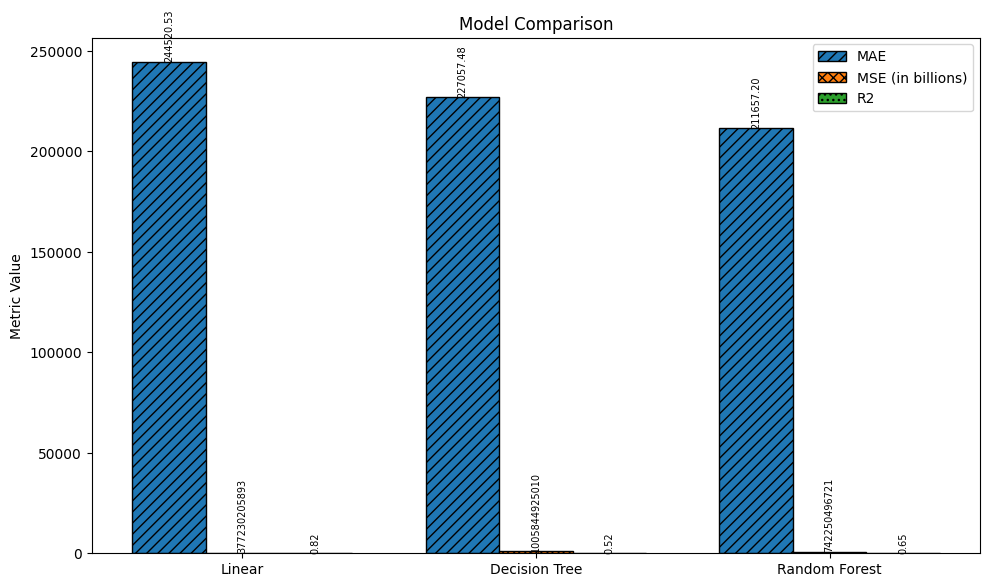

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = ["Linear", "Decision Tree", "Random Forest"]

# Metrics (same as evaluation)
mae = [
    mean_absolute_error(y_test, y_pred_lr),
    mean_absolute_error(y_test, y_pred_dt),
    mean_absolute_error(y_test, y_pred_rf)
]

mse = [
    mean_squared_error(y_test, y_pred_lr),
    mean_squared_error(y_test, y_pred_dt),
    mean_squared_error(y_test, y_pred_rf)
]

r2 = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf)
]

# 🔥 Scale MSE for better visualization
mse_scaled = [val / 1e9 for val in mse]   # convert to billions

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))

# Black & white friendly bars
bars1 = plt.bar(x - width, mae, width, label="MAE", hatch='///', edgecolor='black')
bars2 = plt.bar(x, mse_scaled, width, label="MSE (in billions)", hatch='xxx', edgecolor='black')
bars3 = plt.bar(x + width, r2, width, label="R2", hatch='...', edgecolor='black')

plt.xticks(x, models)
plt.ylabel("Metric Value")
plt.title("Model Comparison")
plt.legend()

# Value labels
def add_labels(bars, is_mse=False):
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if is_mse:
            label = f'{mse[i]:.0f}'   # show original MSE value
        else:
            label = f'{height:.2f}'
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 label,
                 ha='center',
                 va='bottom',
                 fontsize=7,
                 rotation=90)

add_labels(bars1)
add_labels(bars2, is_mse=True)
add_labels(bars3)

plt.tight_layout()
plt.savefig("model_comparison_final.png", dpi=300)
plt.show()

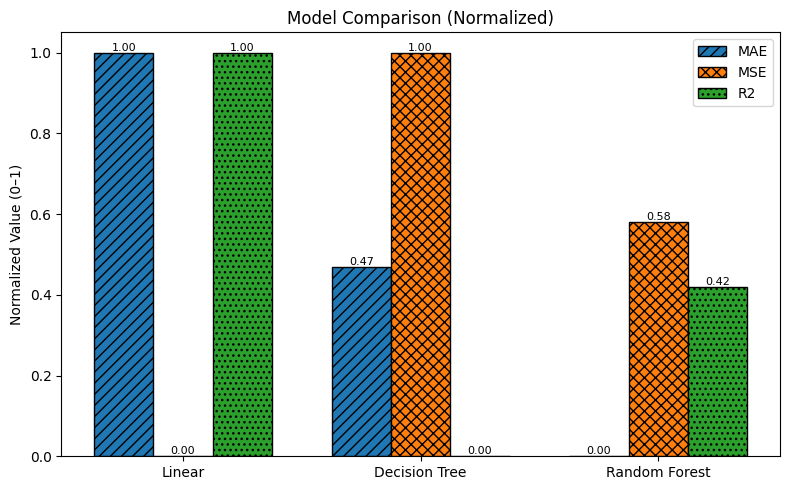

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = ["Linear", "Decision Tree", "Random Forest"]

# Original values
mae = [
    mean_absolute_error(y_test, y_pred_lr),
    mean_absolute_error(y_test, y_pred_dt),
    mean_absolute_error(y_test, y_pred_rf)
]

mse = [
    mean_squared_error(y_test, y_pred_lr),
    mean_squared_error(y_test, y_pred_dt),
    mean_squared_error(y_test, y_pred_rf)
]

r2 = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf)
]

# 🔥 Normalize function (0 to 1)
def normalize(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min())

mae_n = normalize(mae)
mse_n = normalize(mse)
r2_n = normalize(r2)

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))

# Black & white friendly
bars1 = plt.bar(x - width, mae_n, width, label="MAE", hatch='///', edgecolor='black')
bars2 = plt.bar(x, mse_n, width, label="MSE", hatch='xxx', edgecolor='black')
bars3 = plt.bar(x + width, r2_n, width, label="R2", hatch='...', edgecolor='black')

plt.xticks(x, models)
plt.ylabel("Normalized Value (0–1)")
plt.title("Model Comparison (Normalized)")
plt.legend()

# Labels (0.x format)
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.tight_layout()
plt.savefig("model_comparison_normalized.png", dpi=300)
plt.show()

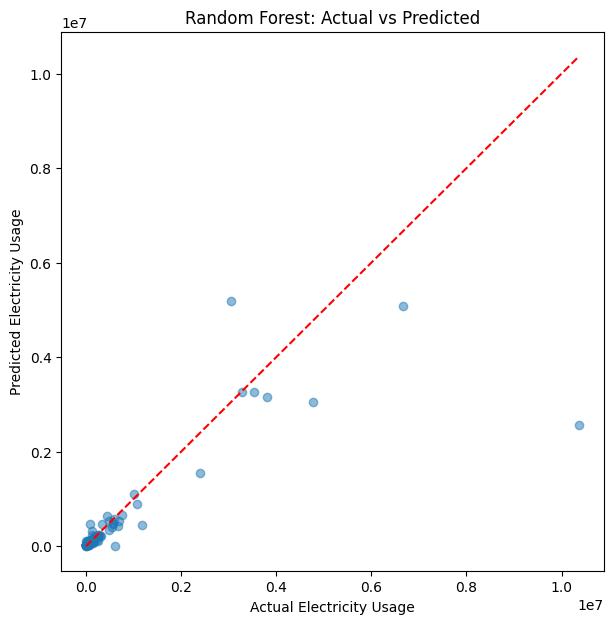

In [ ]:
# Step 9 — Visualization of Predictions
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Electricity Usage')
plt.ylabel('Predicted Electricity Usage')
plt.title('Random Forest: Actual vs Predicted')
plt.show()

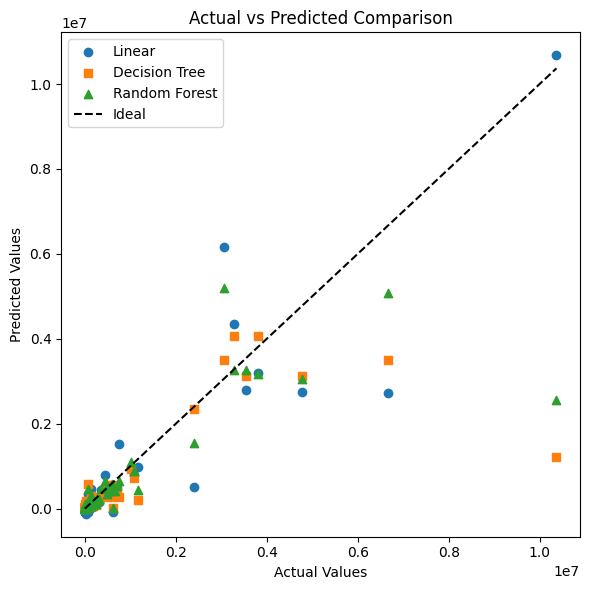

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

# Plot for each model with different markers (important for B/W)
plt.scatter(y_test, y_pred_lr, marker='o', label='Linear')
plt.scatter(y_test, y_pred_dt, marker='s', label='Decision Tree')
plt.scatter(y_test, y_pred_rf, marker='^', label='Random Forest')

# Ideal line (Perfect Prediction)
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         linestyle='--', color='black', label='Ideal')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Comparison")
plt.legend()

plt.tight_layout()
plt.savefig("prediction_visualization.png", dpi=300)

plt.show()


Feature Importances:
                 Feature  Importance
3         Building Area    0.510838
2  Peak Electric Demand    0.486711
1         Current Solar    0.002452
0                  Year    0.000000


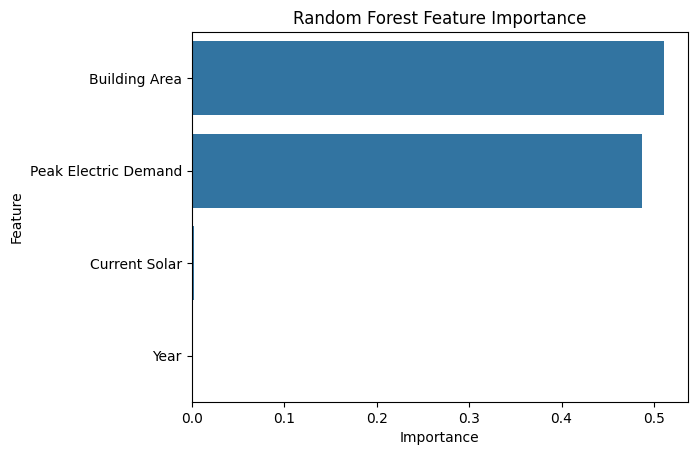

In [ ]:
# Step 10 — Feature Importance (Random Forest)
importances = rf.feature_importances_
feature_importance = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print("\nFeature Importances:\n", feature_importance)
# Optional: plot feature importance
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Random Forest Feature Importance')
plt.show()

In [ ]:
# Step 11 — Final Prediction System
# Example: predict electricity usage for new data
new_data = pd.DataFrame({
    'Year': [2026],
    'Current Solar': [50],
    'Peak Electric Demand': [120],
    'Building Area': [5000]
})
# Normalize new data
new_data_scaled = scaler.transform(new_data)
predicted_usage = rf.predict(new_data_scaled)
print("Predicted Electricity Usage:", predicted_usage[0])

Predicted Electricity Usage: 203264.32


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}
# Initialize model
rf = RandomForestRegressor(random_state=42)
# Randomized Search CV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    verbose=2,
    random_state=42,
    n_jobs=-1
)
# Fit on training data
random_search.fit(X_train, y_train)
# Best parameters
print("Best Parameters:", random_search.best_params_)
# Predict with best model
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)
# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

Best Parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}
MAE: 241150.05873385046
MSE: 590745408011.0532
R²: 0.7175159372816642


In [ ]:
import joblib
# Save model
joblib.dump(best_rf, "energy_rf_model.pkl")
# Save the scaler too (if used)
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
def predict_energy(new_data):
    """
    new_data: dict of feature values
    Example:
    new_data = {
        'Year': 2025,
        'Current Solar': 50,
        'Peak Electric Demand': 120,
        'Building Area': 5000
    }
    """
    import pandas as pd
    # Convert to DataFrame
    df = pd.DataFrame([new_data])
    # Load scaler and model
    scaler = joblib.load("scaler.pkl")
    model = joblib.load("energy_rf_model.pkl")
    # Scale features
    X_new_scaled = scaler.transform(df)
    # Predict
    prediction = model.predict(X_new_scaled)
    return prediction[0]

# Example usage
new_building = {
    'Year': 2025,
    'Current Solar': 50,
    'Peak Electric Demand': 120,
    'Building Area': 5000
}
predicted_energy = predict_energy(new_building)
print("Predicted Energy Consumption:", predicted_energy)

Predicted Energy Consumption: 220511.68334185408
